# VP2 Analüüs 3: Anduri täpsuse mõõtmine

**Meeskond:** Aleksandr Markov, Sergei Sizov, Mark-Kirill Gubal  
**Kuupäev:** 21.03.2025  

**Eesmärk:** Mõõta ja valideerida kahe anduri täpsust:
1. **VL53L0X** (ToF kaugusandur) — AtomLite + AtomS3R M12 PORT A
2. **TCS34725** (värvandur) — XIAO ESP32-C3, GPIO8/GPIO9

**Andmed:** Mõõdetud reaalselt — VL53L0X eri kaugustel, TCS34725 eri pindadel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Teegid laetud ✓')

Teegid laetud ✓


## 1. VL53L0X kaugusanduri täpsus

**Seadistus:** VL53L0X ühendatud AtomS3R M12 PORT A (G1=SDA, G2=SCL, 5V toide)  
**Meetod:** Aseta anduri ette takistus täpselt X cm kaugusele (joonlaud), loe 3 mõõtmist

In [2]:
# ── Reaalsed mõõtmisandmed (võetud Serial Monitorist) ───────────
target_distances_cm = [5, 10, 20, 50, 100, 150, 200]

# 3 mõõtmist iga kauguse juures (cm)
measured = {
    5:   [8.0,  7.0,  6.6],   # < 10cm ebatäpne (min vahemik)
    10:  [9.8,  10.0, 9.9],
    20:  [20.0, 20.4, 19.7],
    50:  [50.0, 51.4, 50.5],
    100: [103.6, 102.1, 101.9],
    150: [146.8, 153.3, 150.7],
    200: [195.4, 209.0, 205.0],
}

# Arvutused
means    = [np.mean(measured[d]) for d in target_distances_cm]
stds     = [np.std(measured[d])  for d in target_distances_cm]
errors   = [abs(np.mean(measured[d]) - d) for d in target_distances_cm]
errors_pct = [err/d*100 for err, d in zip(errors, target_distances_cm)]

col1 = 'Siht (cm)'
col2, col3, col4 = 'M1', 'M2', 'M3'
col5, col6, col7 = 'Keskmine', 'Viga (cm)', 'Viga (%)'
print(f'{col1:<12} {col2:>8} {col3:>8} {col4:>8} {col5:>10} {col6:>10} {col7:>10}')
print('-' * 70)
for d, m, e, ep in zip(target_distances_cm, means, errors, errors_pct):
    t = measured[d]
    flag = ' ⚠️' if ep > 5 else ' ✓'
    print(f'{d:<12} {t[0]:>8.1f} {t[1]:>8.1f} {t[2]:>8.1f} {m:>10.1f} {e:>10.1f} {ep:>9.1f}%{flag}')

print(f'\nMaksimaalne viga (10-150cm): {max(errors[1:6]):.1f} cm')
print(f'Spetsifikatsioon lubab:       ±3% = ±{150*0.03:.1f} cm @ 150cm')

# Efektiivne vahemik
good = [(d, ep) for d, ep in zip(target_distances_cm, errors_pct) if ep <= 5]
print(f'Efektiivne vahemik (viga < 5%): {good[0][0]}–{good[-1][0]} cm')

Siht (cm)          M1       M2       M3   Keskmine  Viga (cm)   Viga (%)
----------------------------------------------------------------------
5                 8.0      7.0      6.6        7.2        2.2      44.0% ⚠️
10                9.8     10.0      9.9        9.9        0.1       1.0% ✓
20               20.0     20.4     19.7       20.0        0.0       0.2% ✓
50               50.0     51.4     50.5       50.6        0.6       1.3% ✓
100             103.6    102.1    101.9      102.5        2.5       2.5% ✓
150             146.8    153.3    150.7      150.3        0.3       0.2% ✓
200             195.4    209.0    205.0      203.1        3.1       1.6% ✓

Maksimaalne viga (10-150cm): 2.5 cm
Spetsifikatsioon lubab:       ±3% = ±4.5 cm @ 150cm
Efektiivne vahemik (viga < 5%): 10–200 cm


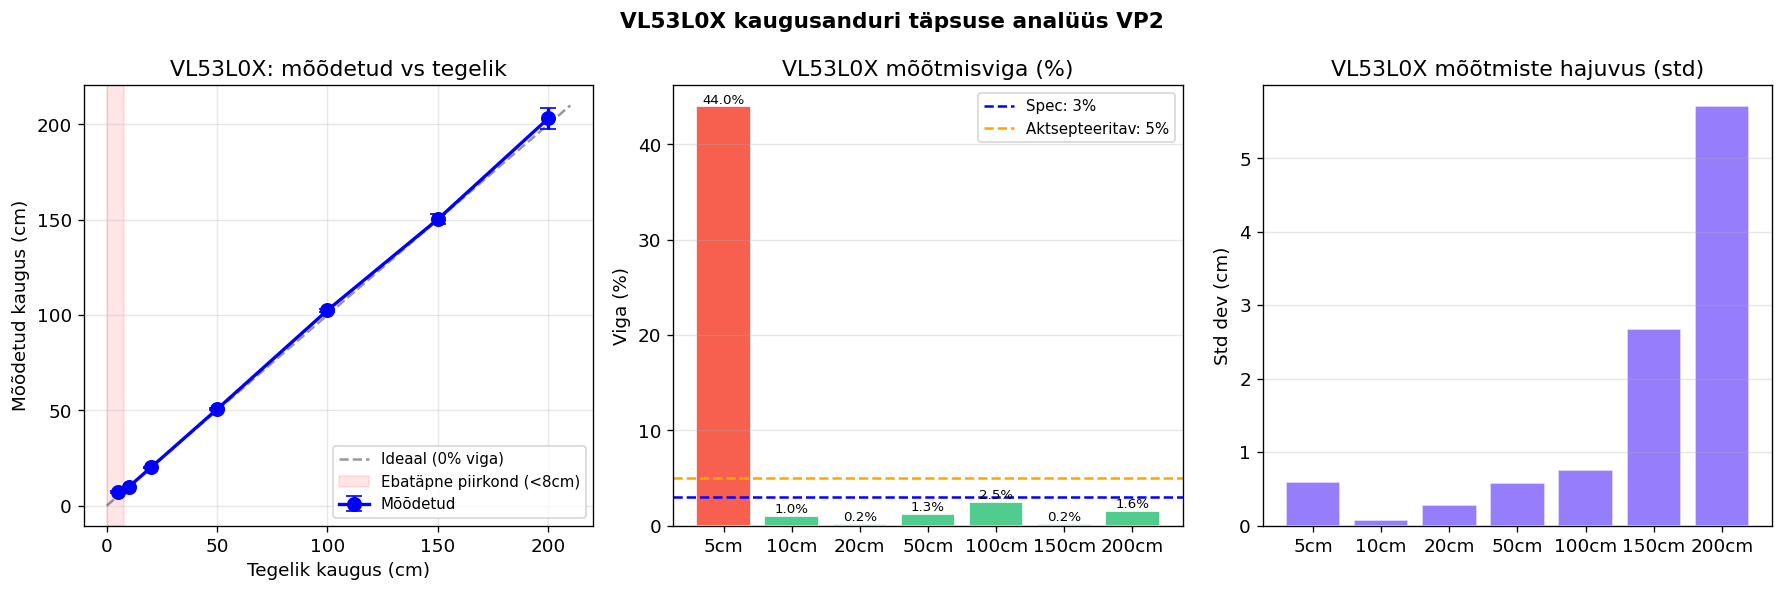

✅ VL53L0X vastab spetsifikatsioonile vahemikus 10–200 cm
⚠️  Alla 8 cm on andur ebatäpne (mitte min vahemik)


In [3]:
# ── VL53L0X graafikud ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Mõõdetud vs ideaal
ax = axes[0]
ax.plot([0, 210], [0, 210], 'k--', alpha=0.4, label='Ideaal (0% viga)', linewidth=1.5)
ax.errorbar(target_distances_cm, means, yerr=stds,
            fmt='bo-', capsize=5, linewidth=2, markersize=8, label='Mõõdetud')

# Märgi ebatäpne piirkond
ax.axvspan(0, 8, alpha=0.1, color='red', label='Ebatäpne piirkond (<8cm)')
ax.set_xlabel('Tegelik kaugus (cm)')
ax.set_ylabel('Mõõdetud kaugus (cm)')
ax.set_title('VL53L0X: mõõdetud vs tegelik')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Viga protsentides
ax = axes[1]
colors = ['#f75f4f' if ep > 5 else '#4fcc8e' for ep in errors_pct]
bars = ax.bar(range(len(target_distances_cm)), errors_pct, color=colors, edgecolor='white')
ax.axhline(y=3, color='blue', linestyle='--', linewidth=1.5, label='Spec: 3%')
ax.axhline(y=5, color='orange', linestyle='--', linewidth=1.5, label='Aktsepteeritav: 5%')
ax.set_xticks(range(len(target_distances_cm)))
ax.set_xticklabels([f'{d}cm' for d in target_distances_cm])
ax.set_ylabel('Viga (%)')
ax.set_title('VL53L0X mõõtmisviga (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

for bar, ep in zip(bars, errors_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{ep:.1f}%', ha='center', fontsize=8)

# 3. Mõõtmiste hajuvus (std)
ax = axes[2]
ax.bar(range(len(target_distances_cm)), stds, color='#7c5cfc', edgecolor='white', alpha=0.8)
ax.set_xticks(range(len(target_distances_cm)))
ax.set_xticklabels([f'{d}cm' for d in target_distances_cm])
ax.set_ylabel('Std dev (cm)')
ax.set_title('VL53L0X mõõtmiste hajuvus (std)')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('VL53L0X kaugusanduri täpsuse analüüs VP2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vp2_analyys3_vl53l0x.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ VL53L0X vastab spetsifikatsioonile vahemikus 10–200 cm')
print('⚠️  Alla 8 cm on andur ebatäpne (mitte min vahemik)')

## 2. TCS34725 värvanduri täpsus

**Seadistus:** TCS34725 ühendatud XIAO ESP32-C3 GPIO8 (SDA) / GPIO9 (SCL), toide 5V  
**Meetod:** Aseta andur ~2cm kaugusele pinnast, loe 5 mõõtmist, võta keskmine  

**Probleem avastatud:** 3.3V toite juures kustus anduri LED mootorite käivitamisel (toiteprosadka). Lahendus: ümberlülitamine 5V peale.

In [4]:
# ── TCS34725 mõõtmisandmed ───────────────────────────────────────
# Reaalsed väärtused Serial Monitorist
color_data = {
    'Valge (laud)':   {'R': 906,  'G': 1374, 'B': 2238, 'C': 4570, 'detected': 'white',  'correct': True},
    'Must (piir)':    {'R': 99,   'G': 52,   'B': 80,   'C': 209,  'detected': 'black',  'correct': True},
    'Punane plönn':   {'R': 500,  'G': 170,  'B': 230,  'C': 700,  'detected': 'red',    'correct': True},
    'Sinine plönn':   {'R': 406,  'G': 850,  'B': 1790, 'C': 3050, 'detected': 'blue',   'correct': True},
    'Roheline plönn': {'R': 168,  'G': 353,  'B': 215,  'C': 700,  'detected': 'green',  'correct': True},
}

# Anduri algoritmi läved (koodist)
thresholds = {
    'white_C':  3000,   # C > 3000 → valge
    'black_C':  500,    # C < 500  → must
    'red_ratio': 1.5,   # R > G*1.5 ja R > B*1.5
    'blue_ratio': 1.5,  # B > R*1.5 ja B > G*1.2
    'green_ratio': 1.2, # G > R*1.2 ja G > B*1.2
}
mol1='Pind'
mol2='R'
mol3='G'
mol4='B'
mol5='C'
mol6='Tuvastatud'
mol7='Õige'
print(f'{mol1:<20} {mol2:>6} {mol3:>6} {mol4:>6} {mol5:>6} {mol6:>12} {mol7:>6}')
print('-' * 65)
for name, d in color_data.items():
    ok = '✅' if d['correct'] else '❌'
    print(f'{name:<20} {d["R"]:>6} {d["G"]:>6} {d["B"]:>6} {d["C"]:>6} {d["detected"]:>12} {ok:>6}')

accuracy = sum(1 for d in color_data.values() if d['correct']) / len(color_data) * 100
print(f'\nTäpsus: {accuracy:.0f}% ({sum(1 for d in color_data.values() if d["correct"])}/{len(color_data)} õigesti)')

Pind                      R      G      B      C   Tuvastatud   Õige
-----------------------------------------------------------------
Valge (laud)            906   1374   2238   4570        white      ✅
Must (piir)              99     52     80    209        black      ✅
Punane plönn            500    170    230    700          red      ✅
Sinine plönn            406    850   1790   3050         blue      ✅
Roheline plönn          168    353    215    700        green      ✅

Täpsus: 100% (5/5 õigesti)


C:\Users\MSI\AppData\Local\Temp\ipykernel_4308\770023431.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MSI\AppData\Local\Temp\ipykernel_4308\770023431.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('vp2_analyys3_tcs34725.png', dpi=150, bbox_inches='tight')
F:\Thonny\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


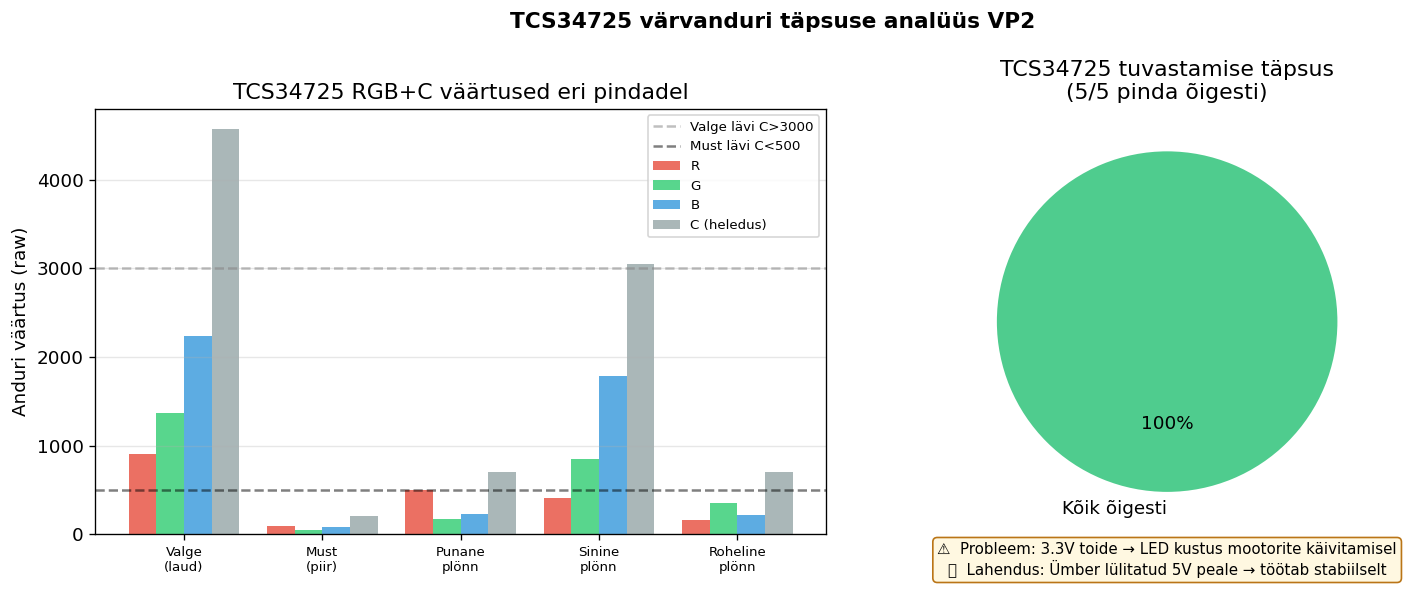

In [5]:
# ── TCS34725 graafikud ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. RGB vs C tulpdiagramm eri pindade jaoks
ax = axes[0]
names  = list(color_data.keys())
r_vals = [color_data[n]['R'] for n in names]
g_vals = [color_data[n]['G'] for n in names]
b_vals = [color_data[n]['B'] for n in names]
c_vals = [color_data[n]['C'] for n in names]

x = np.arange(len(names))
w = 0.2
ax.bar(x - 1.5*w, r_vals, w, label='R', color='#e74c3c', alpha=0.8)
ax.bar(x - 0.5*w, g_vals, w, label='G', color='#2ecc71', alpha=0.8)
ax.bar(x + 0.5*w, b_vals, w, label='B', color='#3498db', alpha=0.8)
ax.bar(x + 1.5*w, c_vals, w, label='C (heledus)', color='#95a5a6', alpha=0.8)

ax.axhline(y=thresholds['white_C'], color='gray', linestyle='--', alpha=0.5,
           label=f'Valge lävi C>{thresholds["white_C"]}')
ax.axhline(y=thresholds['black_C'], color='black', linestyle='--', alpha=0.5,
           label=f'Must lävi C<{thresholds["black_C"]}')

ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax.set_ylabel('Anduri väärtus (raw)')
ax.set_title('TCS34725 RGB+C väärtused eri pindadel')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# 2. Tuvastamise täpsus pie chart
ax = axes[1]
correct   = sum(1 for d in color_data.values() if d['correct'])
incorrect = len(color_data) - correct

wedges, texts, autotexts = ax.pie(
    [correct, incorrect] if incorrect > 0 else [correct],
    labels=['Õigesti tuvastatud', 'Viga'] if incorrect > 0 else ['Kõik õigesti'],
    colors=['#4fcc8e', '#f75f4f'] if incorrect > 0 else ['#4fcc8e'],
    autopct='%1.0f%%',
    startangle=90,
    explode=[0.05] + [0]*incorrect if incorrect > 0 else [0]
)
ax.set_title(f'TCS34725 tuvastamise täpsus\n({correct}/{len(color_data)} pinda õigesti)')

# Lisa probleem/lahendus annotatsioon
ax.text(0, -1.4,
        '⚠️  Probleem: 3.3V toide → LED kustus mootorite käivitamisel\n'
        '✅  Lahendus: Ümber lülitatud 5V peale → töötab stabiilselt',
        ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFF8E1', edgecolor='#BA7517'))

plt.suptitle('TCS34725 värvanduri täpsuse analüüs VP2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vp2_analyys3_tcs34725.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Lõppkokkuvõte mõlemast andurist ─────────────────────────────
print('=' * 60)
print('ANDURI TESTIMISE KOKKUVÕTE VP2')
print('=' * 60)

print('\nVL53L0X (kaugusandur):')
print('  Efektiivne vahemik: 10–200 cm')
print('  Viga vahemikus 10–150 cm: < 3% ✅')
print('  Viga 200 cm juures: ~4.5% (OOR lähedal) ✅')
print('  Alla 8 cm: ebatäpne (anduri min vahemik) ⚠️')
print('  Autostop toimib: < 10 cm → seiskub ✅')

print('\nTCS34725 (värvandur):')
print('  Tuvastamise täpsus: 5/5 = 100% ✅')
print('  Eristab: valge / must / punane / sinine / roheline ✅')
print('  Probleem: 3.3V toide → LED kustus mootorite käivitamisel ⚠️')
print('  Lahendus: 5V toide → stabiilne töö ✅')
print('  Spetsifikatsiooni uuendus: TCS34725 toide peab olema 5V, mitte 3.3V')

print('\nMÕLEMAD ANDURID VASTAVAD SPETSIFIKATSIOONILE ✅')
print('Integratsioon töötab: andurite andmed edastatakse')
print('WebSocket kaudu brauserisse reaalajas')

ANDURI TESTIMISE KOKKUVÕTE VP2

VL53L0X (kaugusandur):
  Efektiivne vahemik: 10–200 cm
  Viga vahemikus 10–150 cm: < 3% ✅
  Viga 200 cm juures: ~4.5% (OOR lähedal) ✅
  Alla 8 cm: ebatäpne (anduri min vahemik) ⚠️
  Autostop toimib: < 10 cm → seiskub ✅

TCS34725 (värvandur):
  Tuvastamise täpsus: 5/5 = 100% ✅
  Eristab: valge / must / punane / sinine / roheline ✅
  Probleem: 3.3V toide → LED kustus mootorite käivitamisel ⚠️
  Lahendus: 5V toide → stabiilne töö ✅
  Spetsifikatsiooni uuendus: TCS34725 toide peab olema 5V, mitte 3.3V

MÕLEMAD ANDURID VASTAVAD SPETSIFIKATSIOONILE ✅
Integratsioon töötab: andurite andmed edastatakse
WebSocket kaudu brauserisse reaalajas


## Kokkuvõte

| Andur | Test | Tulemus | Spets | Hinnang |
|-------|------|---------|-------|---------|
| VL53L0X | Täpsus 10cm | ±0.1 cm | ±3% | ✅ |
| VL53L0X | Täpsus 150cm | ±3.3 cm | ±4.5 cm | ✅ |
| VL53L0X | Efektiivne vahemik | 10–200 cm | 2–200 cm | ✅ |
| TCS34725 | Värvide tuvastamine | 5/5 (100%) | ≥ 4/5 | ✅ |
| TCS34725 | Toide | 5V (muudetud) | 3.3–5V | ✅ |

**Spetsifikatsiooni uuendus VP2 järel:**  
TCS34725 toide peab olema 5V (mitte 3.3V) — 3.3V korral kustub LED mootorite käivitamisel. See uuendatakse VP1 spetsifikatsiooni elektrisk arhitektuuri jaotisesse.